In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
df= pd.read_csv('/content/Student_Performance.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df=pd.get_dummies(df,columns=['Extracurricular Activities'])

In [7]:
df.drop(['Extracurricular Activities_Yes'],axis=1,inplace=True)

In [8]:
x=df.drop('Performance Index',axis=1)
y=df['Performance Index']


In [9]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (8000, 5)
Testing size: (2000, 5)


In [10]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred=model.predict(X_test)

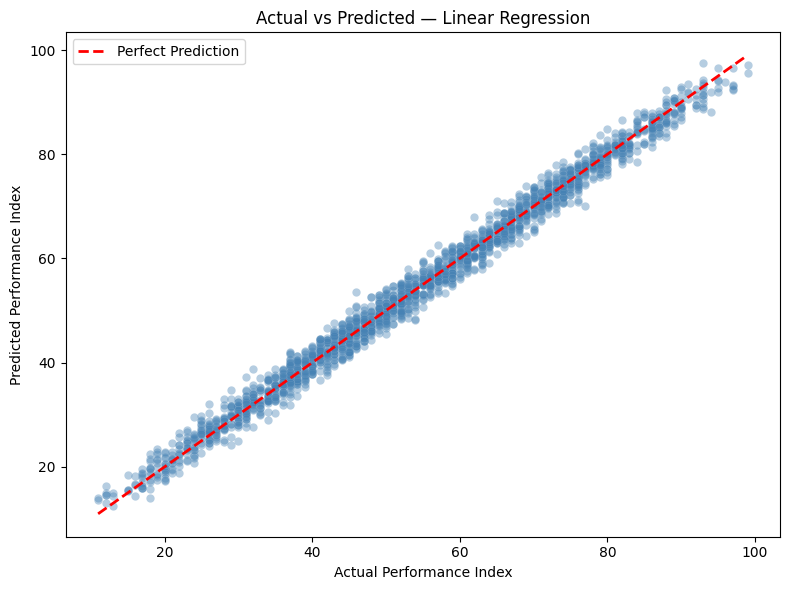

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.1)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')




plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

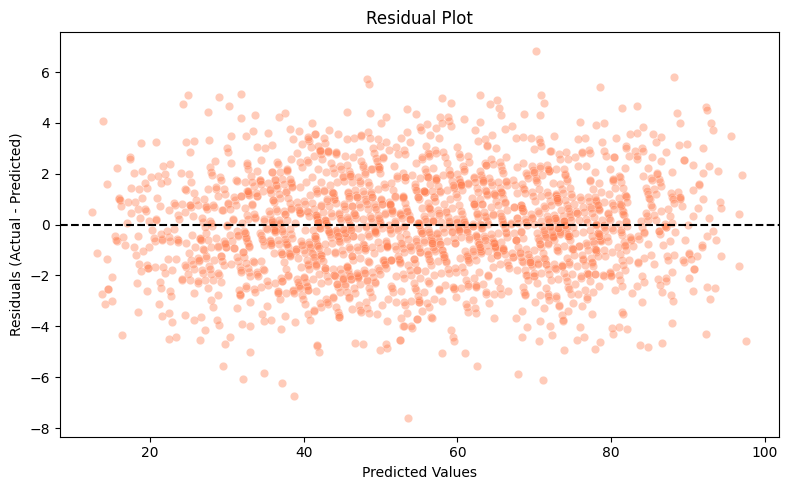

In [13]:
# 2. Residual Plot (shows where model goes wrong)
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='coral', edgecolors='white', linewidth=0.3)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [14]:
# 3. Print clean comparison table
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 35)
print("       MODEL PERFORMANCE")
print("=" * 35)
print(f"  MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"  MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"  R²   : {r2_score(y_test, y_pred):.4f}")
print("=" * 35)

       MODEL PERFORMANCE
  MAE  : 1.61
  MSE  : 4.08
  RMSE : 2.02
  R²   : 0.9890
